# HR Analytics: Employee Attrition Analysis & Prediction

## Objective
The objective of this project is to analyze employee data to identify the key factors influencing employee attrition and build a machine learning model to predict whether an employee is likely to leave the company.

In [125]:
from ast import increment_lineno
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

In [126]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [127]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [128]:
df.shape

(1470, 35)

In [82]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [84]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [85]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [86]:
df.duplicated().sum()

np.int64(0)

In [87]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [88]:
df["Attrition"].value_counts(normalize=True) * 100

,proportion
Attrition,
No,83.877551
Yes,16.122449


In [89]:
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


In [130]:
df = df.drop(columns=["EmployeeCount", "Over18", "StandardHours"])

In [131]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [92]:
df.shape

(1470, 32)

In [93]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [94]:
df["Attrition"].value_counts(normalize=True) * 100

,proportion
Attrition,
No,83.877551
Yes,16.122449


The dataset contains 1470 employee records. Around 84% of employees remained with the company, while approximately 16% left. This indicates that employee attrition is relatively low but still significant enough to analyze.

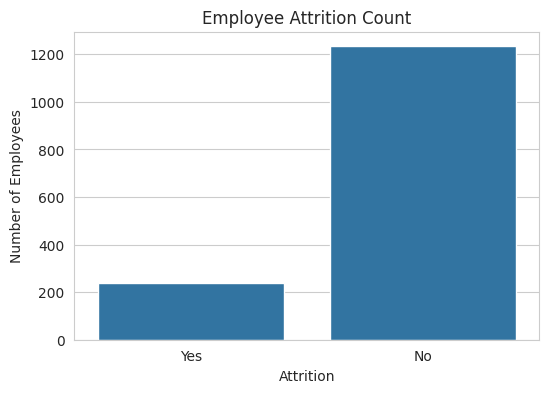

In [95]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

# Observation

- Total Employees: 1470
- Employees Stayed: 1233 (83.9%)
- Employees Left: 237 (16.1%)

# Business Insight

The majority of employees remained with the company, while around 16% left. Although attrition is relatively low, understanding the factors influencing employee turnover can help HR improve retention strategies and reduce hiring costs.

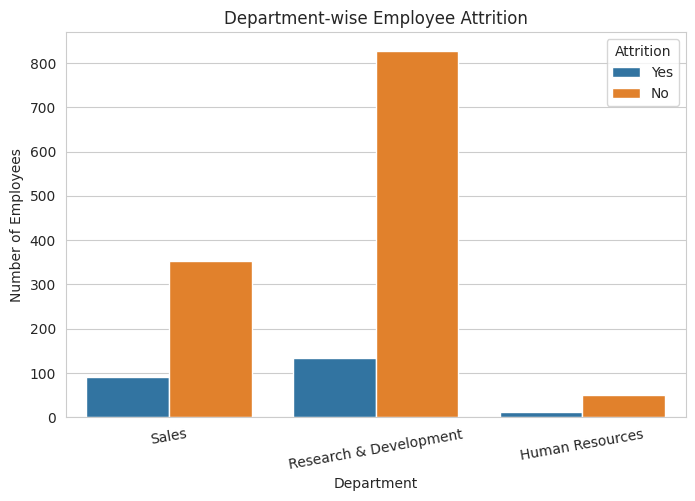

In [96]:
#Department-wise Attrition
#Which department experiences the highest employee attrition?

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)

plt.title("Department-wise Employee Attrition")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.xticks(rotation=10)

plt.show()

#Observation

- Research & Development has the highest number of employees.
- Sales is the second largest department.
- Human Resources has the smallest workforce.
- Research & Development also shows the highest number of employees leaving, followed by Sales.

In [97]:
#Department-wise Attrition Rate
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

department_attrition


Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


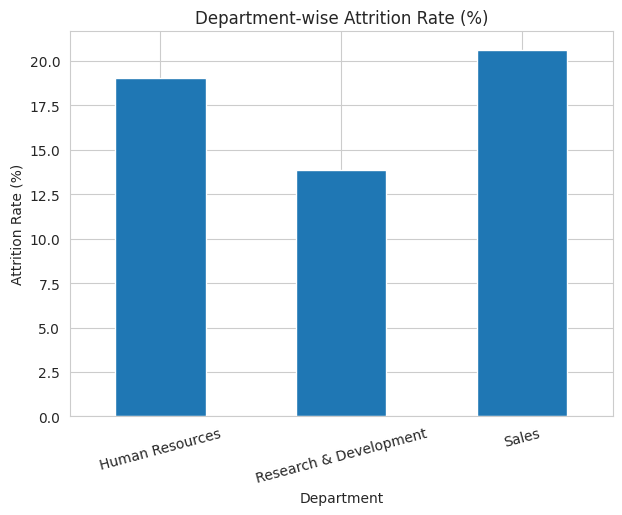

In [98]:
#percentage chart
department_attrition["Yes"].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Department-wise Attrition Rate (%)")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15)

plt.show()

## Observation

- Sales has the highest employee attrition rate (approximately 20.6%).
- Human Resources has the second highest attrition rate (approximately 19%).
- Research & Development has the lowest attrition rate (approximately 13.8%) despite having the largest workforce.

## Business Insight

The Sales department experiences the highest employee turnover relative to its workforce size. This may indicate challenges such as higher work pressure, demanding sales targets, or employee burnout.

## Recommendation

The HR team should prioritize employee retention initiatives in the Sales department by analyzing workload, providing career growth opportunities, and improving employee engagement.

#Overtime vs Attrition


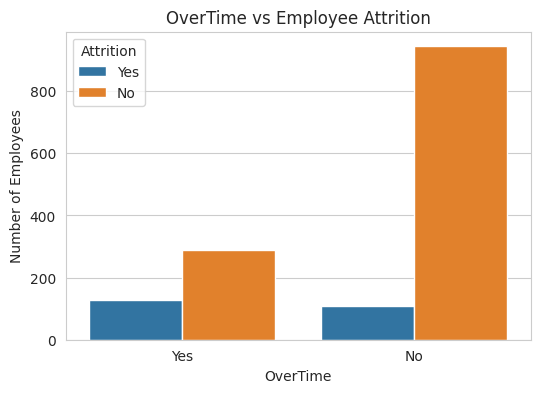

In [99]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title("OverTime vs Employee Attrition")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")

plt.show()

In [100]:
overtime_attrition = pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

overtime_attrition

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


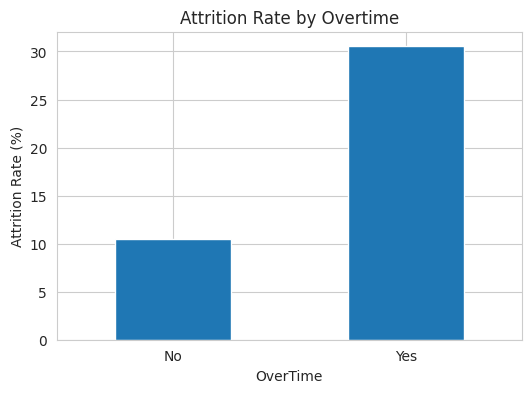

In [101]:
overtime_attrition["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Attrition Rate by Overtime")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.show()

## Observation

- Employees who do not work overtime have an attrition rate of approximately **10.4%**.
- Employees who work overtime have an attrition rate of approximately **30.5%**.
- The attrition rate for employees working overtime is nearly three times higher.

## Business Insight

Overtime appears to be a major factor associated with employee attrition. Employees who frequently work overtime may experience higher stress levels, work-life imbalance, and burnout, increasing the likelihood of leaving the organization.

## Recommendation

The HR department should monitor overtime patterns, promote healthy work-life balance, review workload distribution, and consider flexible scheduling to reduce employee burnout and improve retention.

In [102]:
Job Satisfaction vs Attrition

SyntaxError: invalid syntax (3628975478.py, line 1)

In [ ]:
job_satisfaction = pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

job_satisfaction

In [ ]:
job_satisfaction.index = [
    "Low",
    "Medium",
    "High",
    "Very High"
]

job_satisfaction["Yes"].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [ ]:
## Observation

- Employees with **Low Job Satisfaction** have the highest attrition rate (approximately 22.8%).
- Employees with **Very High Job Satisfaction** have the lowest attrition rate (approximately 11.3%).
- Attrition decreases as job satisfaction improves, although the difference between Medium and High satisfaction is relatively small.

## Business Insight
Job satisfaction appears to have a significant influence on employee retention. Employees who are dissatisfied with their jobs are more likely to leave the organization, while employees with very high job satisfaction tend to stay longer.


## Work-Life Balance vs Attrition

Does work-life balance affect employee attrition?

In [ ]:
worklife = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

worklife

In [ ]:
worklife.index = [
    "Bad",
    "Good",
    "Better",
    "Best"
]

In [ ]:
worklife["Yes"].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.show()

### 📊 Observation

- Employees with **Bad** work-life balance have the highest attrition rate (approximately 31%).
- Employees with **Better** work-life balance have the lowest attrition rate (approximately 14%).
- Employees with **Good** and **Best** work-life balance show similar attrition rates.

### 💼 Business Insight

Poor work-life balance is strongly associated with higher employee attrition. Employees experiencing poor balance between work and personal life are more likely to leave the organization.

### 💡 Recommendation

The HR department should promote flexible working hours, encourage employee wellness initiatives, monitor excessive workloads, and support work-life balance programs to improve employee retention.

Does Monthly Income influence employee attrition?

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title(
    "Monthly Income by Attrition",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Attrition", fontsize=12)
plt.ylabel("Monthly Income", fontsize=12)

plt.show()

### 📊 Observation

- Employees who left the company generally have lower monthly incomes.
- Employees who stayed have a higher median monthly income.
- The distribution of monthly income is wider among employees who remained with the company.
- A small number of high-income employees exist in both groups as outliers.

### 💼 Business Insight

Monthly income appears to be associated with employee retention. Employees with lower salaries are more likely to leave the organization, suggesting that compensation may influence employee satisfaction and long-term retention.

### 💡 Recommendation

The HR department should regularly review compensation structures, ensure competitive salaries, and provide clear career progression opportunities to improve employee retention, particularly for lower-income employees.


Age vs Attrition

Does age influence employee attrition?

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)

plt.title(
    "Age Distribution by Attrition",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Attrition", fontsize=12)
plt.ylabel("Age", fontsize=12)

plt.show()

### 📊 Observation

- Employees who left the company tend to be younger than those who stayed.
- The median age of employees who left is approximately 32 years.
- The median age of employees who remained is approximately 36 years.
- The employees who stayed also show a wider age distribution.

### 💼 Business Insight

Younger employees appear to have a higher likelihood of leaving the organization. This may be due to career exploration, better job opportunities, or faster career growth expectations during the early stages of their careers.

### 💡 Recommendation

The HR department should focus on retaining early-career employees by providing mentorship programs, career development plans, learning opportunities, and clear promotion pathways.

Correlation Heatmap

In [ ]:
plt.figure(figsize=(16,10))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.show()

### 📊 Observation

- Monthly Income has a strong positive correlation with Job Level.
- Total Working Years is positively correlated with Monthly Income.
- Years at Company, Years in Current Role, and Years with Current Manager are strongly correlated.
- Most other numerical features show weak or moderate correlations.

### 💼 Business Insight

Employees with higher job levels generally earn higher salaries. Experience-related features such as total working years and years at the company are closely related, indicating that experienced employees tend to hold senior positions and receive higher compensation.

### 💡 Recommendation

When building machine learning models, highly correlated features should be monitored to avoid redundancy. Feature importance analysis can help identify the most influential variables.

# Machine Learning

## Data Preprocessing

In [ ]:
df.select_dtypes(include="object").columns

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = le.fit_transform(df[column])

In [ ]:
df.head()

Split Features and Target

In [ ]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [ ]:
print(X.shape)
print(y.shape)

Split into Training and Testing Data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Verify the Split

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

Our First Machine Learning Model

## Model 1: Logistic Regression

In [132]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Check First 10 Predictions

In [133]:
print("Actual :", y_test.values[:10])
print("Predicted:", y_pred[:10])

Actual : [0 0 1 0 0 0 0 0 0 0]
Predicted: [0 0 0 0 0 0 0 0 0 0]


Evaluate Accuracy

In [135]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8775510204081632


Accuracy is the percentage of correctly predicted observations out of the total observations.

Confusion Matrix

In [137]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[252,   3],
       [ 33,   6]])

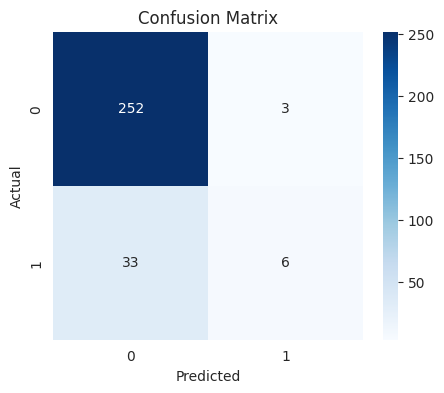

In [138]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 📊 Observation
Logistic Regression achieved an accuracy of 87.41% on the test dataset.
The model correctly classified 252 out of 255 employees who stayed, indicating excellent performance for the majority class.
However, it correctly identified only 6 out of 39 employees who left, showing lower recall for the attrition class due to class imbalance.


### 💼 Business Insight
The Logistic Regression model is effective at predicting employee retention but is less successful at identifying employees who are likely to leave. This occurs because the dataset contains significantly fewer attrition cases than retention cases, causing the model to favor the majority class

### 💡 Recommendation
To improve prediction of employee attrition, future work should focus on handling class imbalance using techniques such as SMOTE, feature engineering, hyperparameter tuning, or more advanced ensemble methods like XGBoost.

Classification Report

In [139]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.15      0.25        39

    accuracy                           0.88       294
   macro avg       0.78      0.57      0.59       294
weighted avg       0.86      0.88      0.84       294



Decision Tree

In [140]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7993197278911565
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       255
           1       0.24      0.23      0.23        39

    accuracy                           0.80       294
   macro avg       0.56      0.56      0.56       294
weighted avg       0.80      0.80      0.80       294



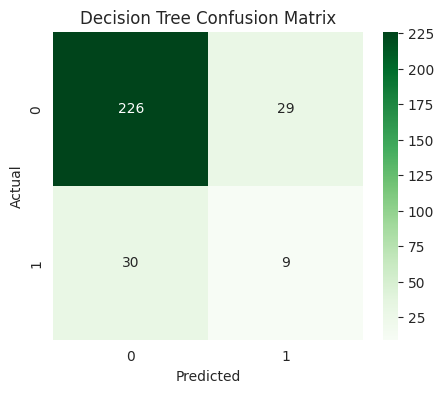

In [141]:
#Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 📊 Observation
Decision Tree achieved an accuracy of 79.93%
It correctly identified most employees who stayed but missed many employees who left.

### 💼 Business Insight

The model showed moderate performance but struggled to accurately predict employee attrition.

### 💡 Recommendation
 Improve performance using ensemble models like Random Forest or XGBoost, along with class-balancing techniques such as SMOTE.

Random Forest

In [142]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))


Accuracy: 0.8809523809523809
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       0.83      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.86      0.56      0.58       294
weighted avg       0.88      0.88      0.84       294



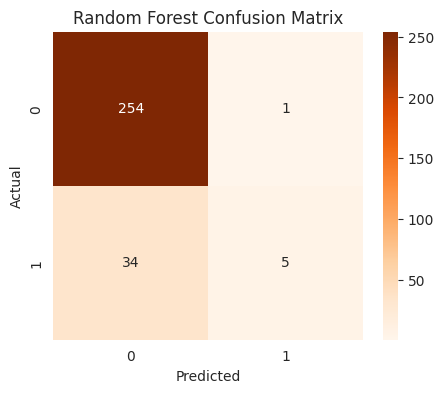

In [150]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [144]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

feature_importance = feature_importances = feature_importance.sort_values(ascending=False)

feature_importance.head(10)

,0
MonthlyIncome,0.078212
OverTime,0.066669
Age,0.061569
DailyRate,0.054087
TotalWorkingYears,0.052491
MonthlyRate,0.048373
HourlyRate,0.047369
DistanceFromHome,0.045999
YearsAtCompany,0.041347
NumCompaniesWorked,0.037951


### 📊 Observation
Random Forest achieved high accuracy and correctly classified most employees who stayed.
However, it still struggled to identify employees who left.

### 💼 Business Insight
The model performed well overall but was affected by the class imbalance in predicting attrition


### 💡 Recommendation
Improve attrition prediction using SMOTE, hyperparameter tuning, or XGBoost.


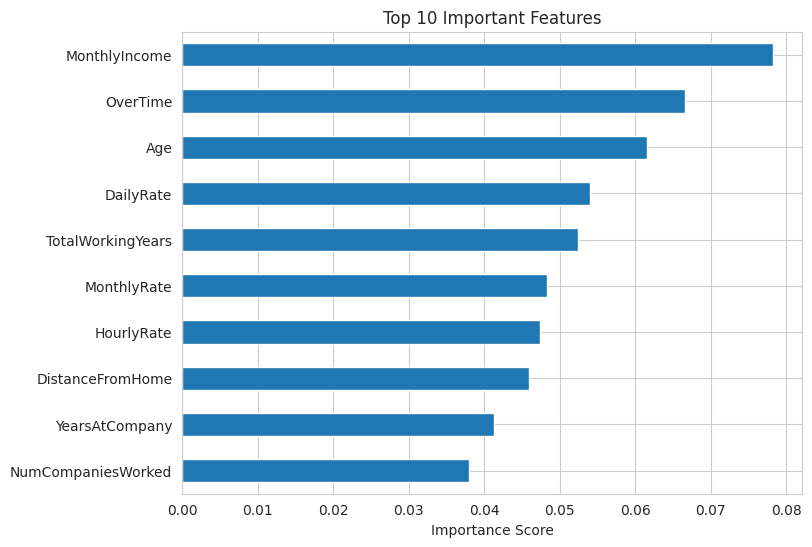

In [151]:
plt.figure(figsize=(8,6))

feature_importance.head(10).plot(kind="barh")

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

# Conclusion

This project analyzed employee data to identify the key factors influencing employee attrition. Through exploratory data analysis, several important patterns were observed:

- Employees working overtime experienced significantly higher attrition.
- Lower job satisfaction was associated with increased employee turnover.
- Poor work-life balance contributed to higher attrition.
- Employees with lower monthly income were more likely to leave.
- Younger employees showed a higher tendency to leave the organization.

Three machine learning models were trained and compared. Logistic Regression achieved the best overall performance for this dataset and was selected as the final model.

This analysis demonstrates how HR Analytics can support data-driven decisions to improve employee retention and workforce planning.

In [155]:
df = df.drop("EmployeeNumber", axis=1)

In [148]:
"EmployeeNumber" in df.columns

True

In [153]:
print("EmployeeNumber" in df.columns)
print("EmployeeNumber" in X.columns)

True
False


In [154]:
print("EmployeeNumber" in X.columns)

False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)